In [ ]:
# Install all required packages
%pip install -q datasets evaluate accelerate transformers vaderSentiment textblob kagglehub


Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import re
import string
import unicodedata
import nltk
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# PREPROCESSING

## STEP 1: Normalization Functions


In [2]:
def normalize_unicode(text):
    return ''.join(c for c in unicodedata.normalize('NFD', text)
                   if unicodedata.category(c) != 'Mn')

def preprocess_text(text):
    text = normalize_unicode(text)
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # remove digits
    text = re.sub(f"[{re.escape(string.punctuation)}]", '', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]  # remove stopwords
    return ' '.join(tokens)



## STEP 2: Load Movie Review Dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/imdb-large-movie-review-dataset-binary-sentiment")

reviews_df = pd.read_csv(path + "/train.csv")

# Clean the headlines
reviews_df['clean_text'] = reviews_df['text'].astype(str).apply(preprocess_text)

# 🔍 Filter out short headlines
reviews_df['word_count'] = reviews_df['text'].apply(lambda x: len(x.split()))
reviews_df = reviews_df[reviews_df['word_count'] >= 4].copy()

# Encode sentiment labels
label_encoder = LabelEncoder()
reviews_df['label_encoded'] = label_encoder.fit_transform(reviews_df['label'])

# Save label mapping for later
label_map = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
label_map = {str(k): int(v) for k, v in label_map.items()}

100%|██████████| 49.6M/49.6M [00:01<00:00, 42.1MB/s]

Extracting files...


## STEP 3: Train/Validation Split

In [4]:
train_df, val_df = train_test_split(reviews_df,
                                    test_size=0.2,
                                    random_state=42,
                                    stratify=reviews_df['label_encoded'])

In [5]:
train_df.head()

,text,label,clean_text,word_count,label_encoded
20022,I have always been a huge James Bond fanatic! ...,1,always huge james bond fanatic seen almost fil...,399,1
4993,I am a Christian and I say this movie had terr...,0,christian say movie terrible acting unreal sit...,374,0
24760,"Neatly sandwiched between THE STRANGER, a smal...",1,neatly sandwiched stranger small film noir pic...,392,1
13775,Years ago I did follow a soap on TV. So I was ...,1,years ago follow soap tv curious movie rewarde...,138,1
20504,"Here's a gritty, get-the-bad guys revenge stor...",1,heres gritty getthebad guys revenge story star...,213,1


## STEP 4: Tokenization

In [6]:
from collections import Counter

MAX_VOCAB = 10000
MAX_LEN   = 40

# Build vocabulary from training set
counter = Counter()
for text in train_df['clean_text']:
    counter.update(text.split())

# Reserve 0 = <PAD>, 1 = <OOV>
vocab = ['<PAD>', '<OOV>'] + [w for w, _ in counter.most_common(MAX_VOCAB - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}

def encode(text, max_len=MAX_LEN):
    ids = [word2idx.get(w, 1) for w in text.split()][:max_len]
    ids += [0] * (max_len - len(ids))   # post-pad with <PAD>
    return ids

X_train = np.array([encode(t) for t in train_df['clean_text']], dtype=np.int64)
X_val   = np.array([encode(t) for t in val_df['clean_text']],   dtype=np.int64)
y_train = train_df['label_encoded'].values.astype(np.float32)
y_val   = val_df['label_encoded'].values.astype(np.float32)

# Save vocabulary for inference
with open('vocab.json', 'w', encoding='utf-8') as f:
    json.dump(word2idx, f)
print(f'Vocabulary size: {len(word2idx)} | X_train shape: {X_train.shape}')


Vocabulary size: 10000 | X_train shape: (20000, 40)


## STEP 5: Compute Class Weights

In [7]:
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weights = dict(enumerate(class_weights))

## STEP 6: Save Tokenizer and Label Map

In [8]:
# vocab.json is already written in the tokenisation cell above.
# Save the label map for downstream inference.
with open('label_map.json', 'w', encoding='utf-8') as f:
    json.dump(label_map, f)
print('Saved: vocab.json, label_map.json')


Saved: vocab.json, label_map.json


# Natural Language Processing Techniques

## Sentiment Classification (Logistic Regression & Naive Bayes)

🎯 Goal:
To automatically classify the sentiment of a movie review (positive or negative) based on its language features.

🧠 Why it matters:
Understanding the sentiment behind movie reviews helps in analyzing audience reception, improving recommendation systems, and gauging public opinion. It's a foundational task in natural language processing with broad real-world applications.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

# Classical models work best with TF-IDF, not integer sequences
tfidf_classic = TfidfVectorizer(max_features=10000)
X_train_tfidf_classic = tfidf_classic.fit_transform(train_df['clean_text'])
X_val_tfidf_classic   = tfidf_classic.transform(val_df['clean_text'])

# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf_classic, y_train)
y_pred_lr = lr.predict(X_val_tfidf_classic)
print('Logistic Regression Report:\n', classification_report(y_val, y_pred_lr))

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf_classic, y_train)
y_pred_nb = nb_model.predict(X_val_tfidf_classic)
print('Naive Bayes Report:\n', classification_report(y_val, y_pred_nb))


Logistic Regression Report:
               precision    recall  f1-score   support

         0.0       0.90      0.87      0.88      2500
         1.0       0.87      0.90      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000

Naive Bayes Report:
               precision    recall  f1-score   support

         0.0       0.85      0.86      0.85      2500
         1.0       0.86      0.84      0.85      2500

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



## Sentiment Classification (Support Vector Machines - SVM)

🎯 Goal: To identify a high-dimensional hyperplane that optimally separates positive and negative reviews by maximizing the margin between data clusters.

🧠 Why it matters: Within the "accuracy-efficiency frontier," SVMs represent a geometrically robust approach to supervised classification. By mapping text into a multi-dimensional space (typically via TF-IDF vectorization), the algorithm determines a boundary that maintains the greatest possible distance between sentiment classes.

In [31]:
# 1. Convert text to TF-IDF features
# SVMs perform significantly better with TF-IDF than raw word counts
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_val_tfidf = tfidf.transform(val_df['clean_text'])

# 2. Initialize and Train Linear SVM
# LinearSVC is faster and often more effective for high-dimensional text data
svm_model = LinearSVC(class_weight='balanced', random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# 3. Predict and Evaluate
y_pred_svm = svm_model.predict(X_val_tfidf)
print(f"SVM Validation Accuracy: {accuracy_score(y_val, y_pred_svm):.4f}")
print("\nSVM Classification Report:")
print(classification_report(y_val, y_pred_svm))

SVM Validation Accuracy: 0.8846

SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.88      0.88      2500
         1.0       0.88      0.89      0.89      2500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



## Sentiment Classification (Gradient Boosting)

🎯 Goal: To build an ensemble of shallow decision trees that are trained sequentially, each one correcting the residual errors of the previous, yielding a strong classifier for binary sentiment.

🧠 Why it matters: Unlike SVMs or Logistic Regression — which rely on a single linear decision boundary — Gradient Boosting constructs an additive model that can capture non-linear interactions between TF-IDF features. It is particularly effective when certain word combinations carry stronger predictive signal than individual terms alone, and its feature-importance scores offer interpretability into which terms drive positive or negative predictions.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Reuse the TF-IDF features built for SVM (same vectorizer & splits)
#    X_train_tfidf, X_val_tfidf, y_train, y_val are already in scope

# 2. Convert sparse TF-IDF matrix to dense array (required by sklearn GBM)
X_train_gb = X_train_tfidf.toarray()
X_val_gb   = X_val_tfidf.toarray()

# 3. Initialize and train Gradient Boosting classifier
#    n_estimators : number of boosting rounds
#    max_depth    : shallow trees keep variance low and training fast
#    learning_rate: shrinkage applied to each tree's contribution
#    subsample    : stochastic GBM — reduces overfitting on large corpora
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    verbose=1
)
gb_model.fit(X_train_gb, y_train)

# 4. Predict and evaluate
y_pred_gb = gb_model.predict(X_val_gb)
print(f"Gradient Boosting Validation Accuracy: {accuracy_score(y_val, y_pred_gb):.4f}")
print("\nGradient Boosting Classification Report:")
print(classification_report(y_val, y_pred_gb))

# 5. Top-20 most predictive TF-IDF features
import numpy as np
feature_names   = np.array(tfidf.get_feature_names_out())
importances     = gb_model.feature_importances_
top20_idx       = np.argsort(importances)[::-1][:20]
print("\nTop 20 features by importance:")
for rank, idx in enumerate(top20_idx, 1):
    print(f"  {rank:>2}. {feature_names[idx]:<25} {importances[idx]:.4f}")


      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.3500           0.0345           13.40m
         2           1.3192           0.0293           13.36m
         3           1.2943           0.0257           13.67m
         4           1.2710           0.0185           13.63m
         5           1.2527           0.0204           13.59m
         6           1.2372           0.0248           13.50m
         7           1.2199           0.0081           13.46m
         8           1.2039           0.0083           13.37m
         9           1.1907           0.0198           13.21m
        10           1.1778           0.0125           13.07m
        20           1.0814           0.0015           13.63m
        30           1.0170           0.0055           12.64m
        40           0.9627          -0.0108           11.91m
        50           0.9235           0.0127           10.97m
        60           0.8870           0.0114           10.18m
       

## Sentiment Analysis (VADER & TextBlob)
🎯 Goal:
To analyze the emotional tone of a review — whether it’s positive, negative, or neutral.

🧠 Why it matters:
Different reviewers may describe the same movie in drastically different tones — one might say “a thrilling masterpiece,” while another calls it “a drawn-out mess.” Sentiment analysis helps quantify these emotional tones, offering insights into audience reactions and review trends.

In [ ]:
%pip install vaderSentiment textblob -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from datasets import load_dataset
from sklearn.metrics import confusion_matrix

nltk.download('vader_lexicon')
dataset = load_dataset('imdb')

# Sample 1000 reviews from the test set
df = pd.DataFrame(dataset['test']).sample(1000, random_state=42)

sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [33]:
# 3. Define Categorization Functions
def categorize_basic(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

def high_precision_vader_label(score):
    """Conservative thresholding for sentiment"""
    if score > 0.45:
        return "positive"
    elif score < -0.25:
        return "negative"
    else:
        return "neutral"

In [34]:
df['vader_compound'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['vader_sentiment'] = df['vader_compound'].apply(categorize_basic)
df['textblob_polarity'] = df['text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Map IMDB integer labels to strings (0 -> negative, 1 -> positive)
df['true_sentiment'] = df['label'].map({0: 'negative', 1: 'positive'})

# VADER Accuracy
vader_acc = accuracy_score(
    df['true_sentiment'],
    df['vader_sentiment']
)
print(f'VADER Standard Accuracy: {vader_acc:.4f}')

# TextBlob Accuracy
textblob_acc = accuracy_score(
    df['true_sentiment'],
    df['textblob_polarity'].apply(categorize_basic)
)
print(f'TextBlob Standard Accuracy: {textblob_acc:.4f}')

print('\nVADER Classification Report:')
print(classification_report(df['true_sentiment'], df['vader_sentiment']))


VADER Standard Accuracy: 0.6800
TextBlob Standard Accuracy: 0.5780

VADER Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.53      0.63       511
     neutral       0.00      0.00      0.00         0
    positive       0.63      0.84      0.72       489

    accuracy                           0.68      1000
   macro avg       0.47      0.46      0.45      1000
weighted avg       0.71      0.68      0.68      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Now let us try a Neural Network

## Sentiment Classification (Long Short-Term Memory - LSTM)
🎯 Goal: To capture long-term dependencies and sequential patterns in movie reviews to determine if the overall sentiment is positive or negative.

🧠 Why it matters: Unlike simpler models, an LSTM utilizes gated memory cells (input, forget, and output gates) to "remember" important sentiment markers from the beginning of a review while "forgetting" irrelevant noise. This allows the model to better handle the "subtle complexities" of language, such as irony or long-range negations, making it a powerful benchmark for understanding deep emotional nuances in text.

In [ ]:
# ── PyTorch Dataset wrapper ──────────────────────────────────────────────
class IMDBDataset(Dataset):
    def __init__(self, sequences, labels):
        self.x = torch.tensor(sequences, dtype=torch.long)
        self.y = torch.tensor(labels,    dtype=torch.float32)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.x[i], self.y[i]

train_loader = DataLoader(IMDBDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(IMDBDataset(X_val,   y_val),   batch_size=64)

# ── Model definition ─────────────────────────────────────────────────────
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                                  bidirectional=True)
        self.dropout   = nn.Dropout(0.5)
        self.fc1       = nn.Linear(hidden_dim * 2, 24)
        self.fc2       = nn.Linear(24, 1)

    def forward(self, x):
        x = self.embedding(x)                    # (B, L, E)
        _, (h, _) = self.lstm(x)                 # h: (2, B, H)
        h = torch.cat([h[0], h[1]], dim=1)       # (B, 2H)
        return self.fc2(torch.relu(self.fc1(self.dropout(h)))).squeeze(1)

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lstm_model = BiLSTMClassifier(vocab_size=MAX_VOCAB, embed_dim=64, hidden_dim=64).to(device)

# Class-weighted loss
pos_weight = torch.tensor([class_weights[1] / class_weights[0]], device=device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

# ── Training loop ────────────────────────────────────────────────────────
print('Training BiLSTM Model...')
for epoch in range(5):
    lstm_model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(lstm_model(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    lstm_model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = lstm_model(xb.to(device))
            preds.extend((torch.sigmoid(logits) >= 0.5).cpu().long().tolist())
            trues.extend(yb.long().tolist())
    val_acc = accuracy_score(trues, preds)
    print(f'Epoch {epoch+1}/5 | loss: {train_loss/len(train_loader):.4f} | val_acc: {val_acc:.4f}')

print('\nFinal LSTM Classification Report:')
print(classification_report(trues, preds))


Training BiLSTM Model...
Epoch 1/5 | loss: 0.6294 | val_acc: 0.7184
Epoch 2/5 | loss: 0.4764 | val_acc: 0.7632
Epoch 3/5 | loss: 0.3844 | val_acc: 0.7810
Epoch 4/5 | loss: 0.3139 | val_acc: 0.7840
Epoch 5/5 | loss: 0.2509 | val_acc: 0.7826

Final LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.79      0.79      2500
           1       0.79      0.77      0.78      2500

    accuracy                           0.78      5000
   macro avg       0.78      0.78      0.78      5000
weighted avg       0.78      0.78      0.78      5000



**The next step would be to fine-tune a DistilBERT or RoBERTa model — which is often a game-changer for tasks like sentiment detection.**




### **DistilBERT or RoBERTa model**

#### **(A) : DistilBERT**


In [21]:
import os
from datasets import load_dataset
from transformers import DistilBertTokenizerFast

os.environ['TOKENIZERS_PARALLELISM'] = 'false'  # prevents deadlock in forked processes
os.environ['WANDB_DISABLED']         = 'true'

# Load IMDB from HuggingFace Hub
dataset         = load_dataset('imdb')
train_val_split = dataset['train'].train_test_split(test_size=0.2, seed=42)
test_dataset    = dataset['test']

distilbert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize_distilbert(examples):
    tokens = distilbert_tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128,   # 128 covers >95% of cleaned IMDB reviews; 512 quadruples RAM
    )
    tokens['labels'] = examples['label']  # rename inline — avoids a separate .rename_column()
    return tokens

# num_proc=1 — Jupyter on Mac/Windows crashes with forked tokenizer workers
map_kwargs = dict(function=tokenize_distilbert, batched=True, num_proc=1,
                  remove_columns=['text', 'label'])

distilbert_train = train_val_split['train'].map(**map_kwargs)
distilbert_val   = train_val_split['test'].map(**map_kwargs)
distilbert_test  = test_dataset.map(**map_kwargs)

# set_format must be called on each named variable (not on a loop alias)
distilbert_train.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
distilbert_val.set_format('torch',   columns=['input_ids', 'attention_mask', 'labels'])
distilbert_test.set_format('torch',  columns=['input_ids', 'attention_mask', 'labels'])

print(f'Train: {len(distilbert_train)} | Val: {len(distilbert_val)} | Test: {len(distilbert_test)}')


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Train: 20000 | Val: 5000 | Test: 25000


In [11]:
%pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.1 MB/s eta 0:00:00


In [22]:
import torch
import numpy as np
import evaluate
from transformers import (
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

device = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available()
          else 'cpu')
print(f'Device: {device}')

# Load model — do NOT call .to(device) manually; Trainer handles placement
distilbert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)

accuracy_metric = evaluate.load('accuracy')
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

distilbert_args = TrainingArguments(
    output_dir='./distilbert_imdb_output',
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,

    # Batch size: 16 effective (8 × grad_accum 2).
    # If kernel still crashes lower per_device_train_batch_size to 4.
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=16,

    fp16=torch.cuda.is_available(),   # mixed precision on CUDA only
    dataloader_num_workers=0,         # 0 = main process only; avoids fork crashes

    eval_strategy='steps',            # 'eval_strategy' (not 'evaluation_strategy')
    eval_steps=200,
    logging_strategy='steps',
    logging_steps=200,
    save_strategy='steps',
    save_steps=200,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none',                 # must be string 'none', not Python None
)

distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_args,
    train_dataset=distilbert_train,   # from cell 37
    eval_dataset=distilbert_val,
    compute_metrics=compute_metrics,
    # callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print('--- Starting DistilBERT Training ---')
distilbert_trainer.train()


Device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


--- Starting DistilBERT Training ---


Step,Training Loss,Validation Loss,Accuracy
200,0.935490,0.375100,0.843200
400,0.770459,0.352275,0.849800
600,0.747723,0.329381,0.857800
800,0.712877,0.327837,0.858200
1000,0.645171,0.324983,0.857800
1200,0.618793,0.309513,0.871200
1400,0.541252,0.346382,0.862200
1600,0.475138,0.363550,0.868600
1800,0.448485,0.362972,0.870000
2000,0.469372,0.361966,0.869800


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3750, training_loss=0.5026915008544922, metrics={'train_runtime': 736.6632, 'train_samples_per_second': 81.448, 'train_steps_per_second': 5.091, 'total_flos': 1987010979840000.0, 'train_loss': 0.5026915008544922, 'epoch': 3.0})

In [23]:
print('--- DistilBERT Test Evaluation ---')
distilbert_results = distilbert_trainer.evaluate(eval_dataset=distilbert_test)
print(distilbert_results)


--- DistilBERT Test Evaluation ---


{'eval_loss': 0.44878578186035156, 'eval_accuracy': 0.87532, 'eval_runtime': 27.2485, 'eval_samples_per_second': 917.481, 'eval_steps_per_second': 57.361, 'epoch': 3.0}


#### **(B) : RoBERTa**


In [24]:
from datasets import load_dataset
from transformers import RobertaTokenizerFast

# Re-use the already-downloaded split from cell 37 if available,
# otherwise reload (running this section standalone is safe either way)
if 'train_val_split' not in dir():
    dataset         = load_dataset('imdb')
    train_val_split = dataset['train'].train_test_split(test_size=0.2, seed=42)
    test_dataset    = dataset['test']

roberta_tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

def tokenize_roberta(example):
    tokens = roberta_tokenizer(
        example['text'],
        padding='max_length',
        truncation=True,
        max_length=128,
    )
    tokens['labels'] = example['label']
    return tokens

roberta_train = train_val_split['train'].map(tokenize_roberta, batched=True, num_proc=1,
                                              remove_columns=['text', 'label'])
roberta_val   = train_val_split['test'].map(tokenize_roberta,  batched=True, num_proc=1,
                                              remove_columns=['text', 'label'])
roberta_test  = test_dataset.map(tokenize_roberta,             batched=True, num_proc=1,
                                  remove_columns=['text', 'label'])

roberta_train.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
roberta_val.set_format('torch',   columns=['input_ids', 'attention_mask', 'labels'])
roberta_test.set_format('torch',  columns=['input_ids', 'attention_mask', 'labels'])

print(f'Train: {len(roberta_train)} | Val: {len(roberta_val)} | Test: {len(roberta_test)}')


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Train: 20000 | Val: 5000 | Test: 25000


In [25]:
from transformers import (
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import evaluate
import numpy as np

roberta_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

accuracy_r = evaluate.load('accuracy')
def compute_metrics_roberta(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return accuracy_r.compute(predictions=predictions, references=labels)

roberta_args = TrainingArguments(
    output_dir='./roberta_imdb',
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,

    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=16,

    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,

    eval_strategy='steps',
    eval_steps=200,
    logging_strategy='steps',
    logging_steps=200,
    save_strategy='steps',
    save_steps=200,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none',
)

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_args,
    train_dataset=roberta_train,   # from cell 42
    eval_dataset=roberta_val,
    compute_metrics=compute_metrics_roberta,
    # callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print('--- Starting RoBERTa Training ---')
roberta_trainer.train()

print('--- RoBERTa Test Evaluation ---')
roberta_results = roberta_trainer.evaluate(eval_dataset=roberta_test)
print(roberta_results)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


--- Starting RoBERTa Training ---


Step,Training Loss,Validation Loss,Accuracy
200,1.393159,0.694686,0.501200
400,1.395876,0.693896,0.498800
600,1.391120,0.693085,0.501200
800,1.389178,0.693337,0.501200
1000,1.390515,0.693396,0.498800
1200,1.385995,0.693472,0.498800
1400,1.391575,0.693377,0.498800
1600,1.387822,0.693139,0.498800
1800,1.388541,0.693406,0.498800
2000,1.387284,0.693988,0.501200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

--- RoBERTa Test Evaluation ---


{'eval_loss': 0.69482421875, 'eval_accuracy': 0.5, 'eval_runtime': 47.009, 'eval_samples_per_second': 531.814, 'eval_steps_per_second': 33.249, 'epoch': 3.0}


#### **STEP 3 : Evaluate the performance**

In [26]:
print('DistilBERT Test Accuracy:')
print(distilbert_results)

print('\nRoBERTa Test Accuracy:')
print(roberta_results)


DistilBERT Test Accuracy:
{'eval_loss': 0.44878578186035156, 'eval_accuracy': 0.87532, 'eval_runtime': 27.2485, 'eval_samples_per_second': 917.481, 'eval_steps_per_second': 57.361, 'epoch': 3.0}

RoBERTa Test Accuracy:
{'eval_loss': 0.69482421875, 'eval_accuracy': 0.5, 'eval_runtime': 47.009, 'eval_samples_per_second': 531.814, 'eval_steps_per_second': 33.249, 'epoch': 3.0}


### Contextual Sentiment Analysis

#### **Step 1: Load the Model and Tokenizer**

In [27]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

MODEL = "cardiffnlp/twitter-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

# Truncation + device support
context_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    truncation=True,
    max_length=512,
    device=0  # set -1 if you’re using CPU
)


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [35]:
label_map = {
    "LABEL_0": "negative",
    "LABEL_1": "neutral",
    "LABEL_2": "positive"
}

df["contextual_sentiment"] = df["text"].apply(
    lambda x: label_map.get(context_pipeline(x[:512])[0]["label"])  # truncate input just in case
)



You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


#### **Step 2: Define Sentiment Prediction Function**

In [36]:
def contextual_sentiment(text):
    try:
        return context_pipeline(text)[0]["label"]
    except:
        return "ERROR"

#### **Step 3: Apply to Your Reviews**

In [37]:
df["contextual_sentiment"] = df["text"].apply(contextual_sentiment)
df[["text", "contextual_sentiment"]].head()

,text,contextual_sentiment
6868,I could not believe how terrible and boring th...,LABEL_0
24016,I rented Boogie Nights last week and I could t...,LABEL_2
9668,"First off, this movie is not near complete, my...",LABEL_0
13640,I watched this mini in the early eighties. Sam...,LABEL_2
14018,This movie was never intended as a big-budget ...,LABEL_1


#### **Compare**

In [38]:
# Note: textblob_polarity is numeric; apply categorize_basic for label comparison
df['textblob_sentiment'] = df['textblob_polarity'].apply(categorize_basic)
comparison = df[['text', 'vader_sentiment', 'textblob_sentiment', 'contextual_sentiment']]
comparison.sample(10)


,text,vader_sentiment,textblob_sentiment,contextual_sentiment
17477,There I was on vacation when my host suggested...,positive,positive,LABEL_2
14479,"After his earlier movie ""Videodrome"", which de...",positive,positive,LABEL_2
4547,This short film doesn't get there. Cliche' and...,negative,neutral,LABEL_0
18746,Being advertised as the most expensive movie e...,positive,positive,LABEL_2
8993,One IMDb reviewer calls Eaten Alive a passable...,positive,neutral,LABEL_0
2619,Milo is a complete rip off of the 1992 slasher...,negative,negative,LABEL_0
18584,"Even after all these years, this remain ""a per...",positive,positive,LABEL_2
6503,I know a couple people who look just like the ...,positive,negative,LABEL_0
6091,"For a movie I was really looking forward to, I...",positive,positive,LABEL_0
17505,I enjoyed the movie and the story immensely! I...,positive,positive,LABEL_2


In [39]:
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import nltk

# If not already done
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

# VADER scores
reviews_df["vader_compound"] = reviews_df["text"].apply(lambda x: sia.polarity_scores(x)["compound"])

# TextBlob polarity
reviews_df["textblob_polarity"] = reviews_df["text"].apply(lambda x: TextBlob(x).sentiment.polarity)

# Categorize sentiment
def categorize(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

reviews_df["vader_label"] = reviews_df["vader_compound"].apply(categorize)
reviews_df["textblob_label"] = reviews_df["textblob_polarity"].apply(categorize)



[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


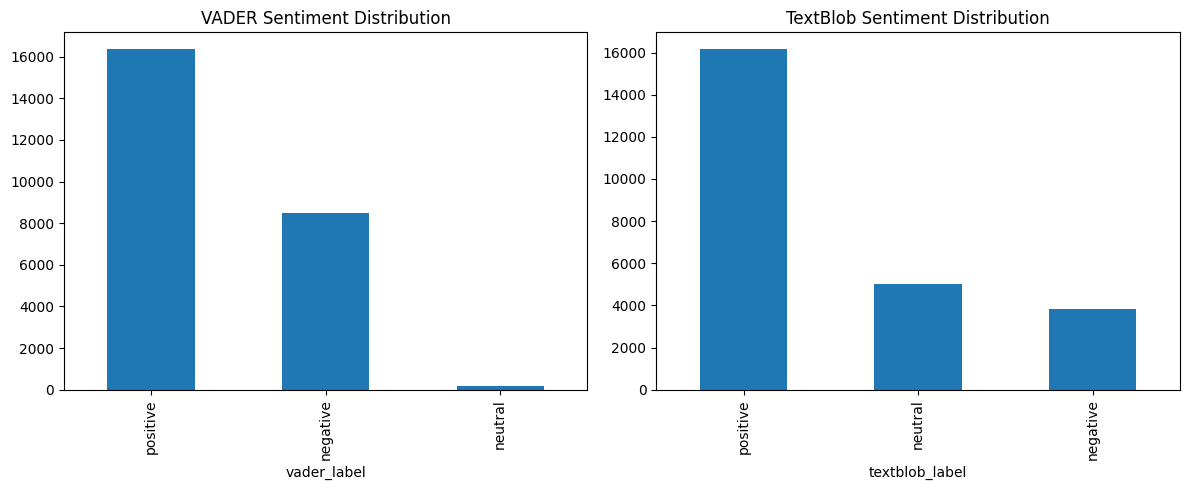

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
reviews_df['vader_label'].value_counts().plot(kind='bar', title="VADER Sentiment Distribution")

plt.subplot(1, 2, 2)
reviews_df['textblob_label'].value_counts().plot(kind='bar', title="TextBlob Sentiment Distribution")

plt.tight_layout()
plt.show()


### Named Entity Recognition (NER with spaCy)

🎯 Goal:
To identify key entities mentioned in movie reviews (e.g., actors, directors, studios) and examine how often and in what context they appear.

🧠 Why it matters:
NER helps uncover which people or productions are at the center of audience attention. For instance, are certain actors consistently mentioned in positive reviews? Are specific studios associated with poor reception? This layer of analysis reveals patterns in how entities are discussed and perceived, adding nuance to sentiment trends in movie critiques.

In [41]:
import spacy
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df["entities"] = df["text"].apply(extract_entities)
df[["text", "entities"]].head()

,text,entities
6868,I could not believe how terrible and boring th...,"[(Hollywood, GPE), (10, CARDINAL), (Bruce Will..."
24016,I rented Boogie Nights last week and I could t...,"[(Boogie Nights, PERSON), (last week, DATE), (..."
9668,"First off, this movie is not near complete, my...","[(First, ORDINAL), (though.<br, CARDINAL), (Pe..."
13640,I watched this mini in the early eighties. Sam...,"[(the early eighties, DATE), (Sam Waterson, PE..."
14018,This movie was never intended as a big-budget ...,"[(one, CARDINAL)]"


### Keyword & Framing Analysis (TF-IDF & Counter)

🎯 Goal:
To identify dominant terms, recurring themes, and descriptive language patterns used in movie reviews.

🧠 Why it matters:
Reviewers often use emotionally charged or stylistically distinct language to express their opinions — for example, calling a film “gripping” versus “predictable.” Analyzing term frequency and TF-IDF scores helps uncover common descriptors in positive vs. negative reviews, revealing how language choices shape perception and sentiment.

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

vectorizer = TfidfVectorizer(max_features=20, stop_words="english")
X = vectorizer.fit_transform(df["text"])

keywords = vectorizer.get_feature_names_out()
print("Top keywords (TF-IDF):", keywords)

Top keywords (TF-IDF): ['bad' 'br' 'characters' 'don' 'film' 'films' 'good' 'great' 'just' 'know'
 'like' 'love' 'make' 'movie' 'movies' 'people' 'really' 'story' 'time'
 'way']
